# 머신러닝 기초와 문제정의

1. 규칙을 구성하는 것과 학습하는 것의 차이

> **노트북 사용전 확인**
>
> 셀을 순서대로 실행하지 않으면 변수상태가 꼬일 수 있다.
> 위에서 아래 순서대로 실행하면서 확인하자.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import build_dataset, FEATURES, SEED

setup()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 20)

print("준비완료")

[폰트] Malgun Gothic / unicode_minus=False
준비완료


---
## 1. 코딩과의 차이점

지금까지 해온 프로그래밍은 **규칙을 사람이 정하는 것**이다.

```python
if 거래량 > 1000000 and 등락률 > 5:
    return "급등주"
```

규칙이 명확하면 코딩이 무조건 좋다. 빠르고, 정확하고, 설명이 가능하다.

다만, **규칙을 사람이 알 수 없을 때**는 다르다.

> "오늘 주가가 오를 종목의 조건은 무엇인가?"

거래량, 등락률, 이동평균, 변동성... 수십개 이상의 변수로 인해 if문 작성이 어렵다.
**머신러닝은 데이터에서 그 규칙을 컴퓨터 찾아내게 하는 방법**이다.

In [3]:
#직접 구현해보자

# 정제및 파생변수 생성을 마친 데이터
df = build_dataset()

# 규칙 : 거래량이 평소보다 2배이상 많고, 20일 평균보다 3%이상 높으면 오른다.
rule = (df["volume_ratio"] > 2.0) & (df["ma20_ratio"] > 1.03)

# 이 규칙이 예측한것과 실제 정답을 비교
# df["target_up"] -> 올랐으면 1, 아니면 0
hit = (rule == df["target_up"]).mean()

print(f" 규칙에 해당하는 날 : {rule.sum():,}건 / {len(df):,}건")
print(f" 규칙의 적중률 : {hit:.4f}")
print()
print(f"전체 상승비율 : {df['target_up'].mean()}")


 규칙에 해당하는 날 : 731건 / 87,480건
 규칙의 적중률 : 0.5099

전체 상승비율 : 0.48954046639231824


> **적중률이 매우매우 낮게 나온다**
>
> 사람이 느낌으로 만든 규칙이기 때문에, 어떤 조건을 어떤 값으로 잡아야하는지 어려움이 있다.
> 조건을 바꿔가며 손으로 찾을 수도 있지만, 변수가 7개만 돼도 조합이 폭발적으로 많다.

- 프로그래밍 : 데이터 + 규칙(사람)을 입력해서 결과를 받는다.
- 머신러닝 : 데이터 + 정답을 입력해서 규칙을 만든다.

> 규칙이 명확하면 프로그램밍을 통해 답을 구하면되고, 
> **규칙을 알 수 없을 때** 머신러닝을 이용해서 규칙을 만들면 된다.

---
## 분류와 회귀 - 무엇을 예측하려고 하는가?

**머신러닝에서는 이 판단이 매우 중요하다.**
| | 분류 | 회귀 |
|---|---|---|
|예측가능한 것|범주|수치|
|질문|오를까?내릴까?|얼마나오를까?|
|출력|up/down|2.7%|
|평가지표|정확도, 정밀도, 재현율|MAE,RMSE...|

**같은 데이터로 두 문제를 다 만들 수 있다.**

In [4]:
# 우리 데이터에는 두가지 정답이 전부있음
# target_ret : 오늘의 수익률 - 수치 -> 회귀용
# target_up : 올랐니? (1/0) - 범주 -> 분류용

sample = df[["code", "date", "target_ret", "target_up"]].head(8)
print(sample.to_string(index=False))

print()
print("같은 행이지만 정답을 두가지로 볼 수 있다.")

 code       date  target_ret  target_up
G0001 2023-10-24    0.015574          1
G0001 2023-10-25   -0.008639          0
G0001 2023-10-26   -0.002960          0
G0001 2023-10-27    0.002676          1
G0001 2023-10-30    0.003128          1
G0001 2023-10-31    0.046732          1
G0001 2023-11-01   -0.001827          0
G0001 2023-11-02    0.011819          1

같은 행이지만 정답을 두가지로 볼 수 있다.


> **평가 지표를 섞어서 사용할 수 없다**
>
> 분류모델같은 경우 MAE,RMSE...을 사용하거나, 회귀모델에 정확도를 쓸 수 없다.
> "정확도 92%"라는 말은 **분류에서만** 의미가 있다.
> 회귀에서 "정확하게 맞혔다"는 개념자체가 성립하지 않는다.

### 기준선 -> 사람이 정한다.

연속값을 범주로 변경하려면 어디서 자를것이가?를 정해야한다 -> **정답의 기준이된다**

In [5]:
#기준선을 바꿔가며 '상승'의 비율이 어떻게 변하는지 보자.

print(f"{'기준선':>10}{'양성비율':>12}{'양성건수':>12}")
print("-"*60)

for th in [0.0, 0.01, 0.02, 0.03, 0.05]:
    positive = (df["target_ret"] > th)
    print(f"{th:>9.0%}{positive.mean():>12.2%}{positive.sum():>12,}")

       기준선        양성비율        양성건수
------------------------------------------------------------
       0%      48.95%      42,825
       1%      29.46%      25,773
       2%      15.30%      13,387
       3%       6.74%       5,894
       5%       1.38%       1,210


> **기준선이 결과를 바꾼다**
>
> 0%를 기준으로 하면 상승, 하락이 거의 반반이다. 5%으로하면 상승이 1.4%밖에 안된다.
>
> 이런 불균형데이터에서는 "전부하락"이라고하면 정확도가 98%가 넘는다.

---
## 3. 학습, 검증 테이터 분리

시험 문제를 미리 알려주고 시험을 보면 당연히 점수가 높게 나온다.

모델도 정확하게 똑같다. **학습에 사용한 데이터로 평가하면 성능이 과대평가**된다.

| 데이터 | 용도 | 비율 |
|---|---|---|
|학습|모델이 규칙을 배움|60~70%|
|검증|하이퍼파라미더 조정|15~20%|
|테스트|최종 성능 측정|15%~20%|

In [6]:
from sklearn.model_selection import train_test_split

# 실습용으로 데이터를 줄여서 가져옴
small = df.sample(5000, random_state=SEED)

X = small[FEATURES]    #입력
y = small["target_up"]  #정답

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                           # 입력, 정답
    test_size=0.2,                  # 학습 8대 테스트2
    random_state=SEED,              # 재현성을 위해서 SEED는 정해둔거다.
    stratify=y,                     # 타깃레벨(y)클래스 비율을 그대로 유지한채 학습데이터와 Test를 분리
)

print(f"X shape : {X.shape} (행수, 피처수)")
print(f"y shape : {y.shape} 1차원")
print()
print(f"학습 : {len(X_train):,}행 상승 비율 : {y_train.mean():.4f}")
print(f"테스트 : {len(X_test):,}행 상승 비율 : {y_test.mean():.4f}")

X shape : (5000, 7) (행수, 피처수)
y shape : (5000,) 1차원

학습 : 4,000행 상승 비율 : 0.4995
테스트 : 1,000행 상승 비율 : 0.4990


> stratify를 빼면 클래스가 쏠린다.
> 
> 테스트 데이터는 마지막에 딱 한번만 테스트로 사용한다.
> 테스트 결과를 보고 모델을 고치면, 그 순간 테스트 데이터가 학습의 관여하게된다.

---
## 4. 시계열 랜덤 분할하면 안된다.

우리 데이터는 날짜가 있는 시계열 데이터다. 여기서 train_test_split을 그냥 사용하면 문제가 발생한다.

```
랜덤분할 - 2026년 데이터로 학습 -> 2024년을 예측 (예측이 아니라 검증이다)
시점분할 - 2023~2025년 데이터로 학습 -> 2026년을 예측
```

In [7]:
# 랜덤분할과 시점분할 기간을 비교

#랜덤 분할
rnd_train, rnd_test = train_test_split(df, test_size=0.2, random_state=SEED)

#시점분할 - 직접 날짜를 기준으로 앞뒤를 자른다.
cutoff = df["date"].quantile(0.8)       # 상위 80%지점의 날짜
seq_train = df[df["date"] <= cutoff]
seq_test = df[df["date"] > cutoff]

print(f"{'랜덤분할':<11}")
print(f"{rnd_train.date.min().date()} ~ {rnd_train.date.max().date()}")
print(f"{rnd_test.date.min().date()} ~ {rnd_test.date.max().date()}")
print()
print(f"{'시점분할':<11}")
print(f"{seq_train.date.min().date()} ~ {seq_train.date.max().date()}")
print(f"{seq_test.date.min().date()} ~ {seq_test.date.max().date()}")


랜덤분할       
2023-10-24 ~ 2026-08-07
2023-10-24 ~ 2026-08-07

시점분할       
2023-10-24 ~ 2026-01-16
2026-01-19 ~ 2026-08-07


> 미래 정보가 섞이면 성능이 비현실적으로 잘 나온다
>
> stratify와 시계열은 함께 사용할 수 없다.

In [8]:
print(f"학습(상승비율) : {seq_train['target_up'].mean()}")
print(f"테스트(상승비율) : {seq_test['target_up'].mean()}")
print()
# 만약 비율이 크게 다르다면 분할 지점을 다시 지정해보도록 한다.

학습(상승비율) : 0.4896689497716895
테스트(상승비율) : 0.4890229885057471



---
## 5. scikit-learn 공통 인터페이스

**모든 모델이 같은 방식으로 동작하는 것**이 가장 큰 scikit-learn의 장점이다.

```python
model = 어떤모델()
moel.fit(X_train, y_train) #학습
pred = model.predict(X_test) #예측
score = model.score(X_test, y_test) #평가
```

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 시점 분할한 데이터
train_s = seq_train.sample(8000, random_state=SEED)
test_s = seq_test.sample(2000, random_state=SEED)

Xtr, ytr = train_s[FEATURES], train_s["target_up"]
Xte, yte = test_s[FEATURES], test_s["target_up"]

models = {
    "LogisticRegression" : LogisticRegression(max_iter=1000, random_state=SEED),
    "DecisionTree" : DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "RandomForest" : RandomForestClassifier(n_estimators=50, max_depth=5,
                                            random_state=SEED, n_jobs=-1)
}

for name, model in models.items():
    model.fit(Xtr, ytr)     #학습
    pred = model.predict(Xte)   #예측
    score = model.score(Xte, yte) #평가
    print(f"{name:<22} score {score:.4f}")

LogisticRegression     score 0.5075
DecisionTree           score 0.4890
RandomForest           score 0.4945


|메서드|역할|
|---|---|
|fit(X,y)|학습|
|predict(X)|예측|
|predict_proba(X)|확률(분류만)|
|score(X, y)|기본 평가 지표|
|transform(X)|변환|

> score()의 의미는 모델마다 다르다.
> 
> 분류모델에서는 정확도, 회귀모델이면 어떤 측정 수치를 반환.

In [10]:
# predict와 predict_proba의 차이를 직접 확인해보자

rf = models["RandomForest"]

pred = rf.predict(Xte)      # 0 또는 1
proba = rf.predict_proba(Xte) # 각 클래스에 속할 확률

print(f"predict       shape {pred.shape}    앞 5개 {pred[:5]}")
print(f"predict_proba shape {proba.shape}")
print()
print("predict_proba의 앞 5행")
print(pd.DataFrame(proba[:5], columns=["하락일 확률", "상승일 확률"]).round(4).to_string(index=False))
print()

print(f"{(proba[:5, 1] >= 0.5).astype(int)}")
# 0.5는 기본값인거고 proba를 통해서 기준을 변경해서 동작을 조절할 수 있다.

predict       shape (2000,)    앞 5개 [1 0 1 0 0]
predict_proba shape (2000, 2)

predict_proba의 앞 5행
 하락일 확률  상승일 확률
 0.4860  0.5140
 0.5471  0.4529
 0.4901  0.5099
 0.5353  0.4647
 0.5477  0.4523

[1 0 1 0 0]


---
## 6. 과적합과 일반화
```
학습 데이터 정확도 99%
테스트 데이터 정확도 63%
```

과적합이란 ** 학습 데이터에 지나치게 맞춰져 ** 노이즈나 세부적인 패턴까지 암기해버린 상태.

우리가 원하는 것은 학습 데이터를 잘 맞히는 것이 아니라,
**처음 보는 데이터에서도 잘 동작하는 것**이다. -> 일반화

In [11]:
depths = [1,2,3,5,8,12,20,None]
rows = []

# max_depth는 의사결정 트리의 최대 분할 깊이

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    m.fit(Xtr, ytr)
    rows.append({
        "max_depth" : "제한없음" if d is None else d,
        "학습" : m.score(Xtr, ytr),
        "테스트" : m.score(Xte, yte),
    })

result = pd.DataFrame(rows)
result["차이"] = result["학습"] - result["테스트"]
print(result.round(4).to_string(index=False))

max_depth     학습    테스트     차이
        1 0.5241 0.4950 0.0291
        2 0.5262 0.4960 0.0302
        3 0.5327 0.4925 0.0402
        5 0.5376 0.4890 0.0486
        8 0.5642 0.4955 0.0688
       12 0.6202 0.4955 0.1247
       20 0.8241 0.5025 0.3216
     제한없음 1.0000 0.5175 0.4825


> **학습성능과 테스트성능은 항상 함께 확인해야한다.**
>
> 테스트 성능만 보면 과적합인지 과소적합인지 알 수 없다. 두 값의 차이를 확인한다.
>
> 학습 성능이 낮으면서 테스트성능도 낮음 -> 과소적합
>
> 학습 성능이 매우 높으면서 테스트성능은 낮음 -> 과대적합
>
> 학습성능이 높으면서 테스트성능도 높아야 적정한 것이다.

---
## 7. 지도학습과 비지도학습

**정답(레이블)을 함께 제공하는가**로 나뉜다.

| |지도학습|비지도학습|
|---|---|---|
|데이터|입력+정답|입력만|
|하는일|정답을 맞히도록 학습|구조,패턴을 찾음|
|예|이 종목은 올랐다/내렸다|비슷한종목끼리 묶는 것|
|평가|정답과 비교|명확한 정답이 없다|

지금까지 우리가 해본것은 전부 지도학습이다.


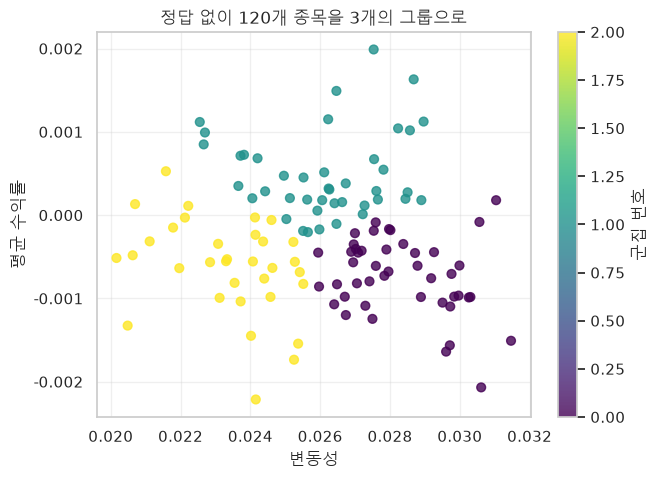

군집별 종목 수 : {0: 45, 1: 42, 2: 33}


In [15]:
# 비지도학습
# 정답(y) 없이 X만 넣는다.

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 종목별 특성(평균수익률, 변동성) 요약
by_code = df.groupby("code").agg(
    평균수익률=("target_ret", "mean"),
    변동성=("target_ret", "std"),
)

# 거리 기반 알고리즘으로 스케일을 맞춘다.
scaled = StandardScaler().fit_transform(by_code)

km = KMeans(n_clusters=3, random_state=SEED, n_init=10)
labels = km.fit_predict(scaled)

fig, ax = plt.subplots(figsize=(7,5))
scatter = ax.scatter(by_code["변동성"], by_code["평균수익률"],
                     c=labels, cmap="viridis", s=40, alpha=0.8)

ax.set_xlabel("변동성")
ax.set_ylabel("평균 수익률")
ax.set_title("정답 없이 120개 종목을 3개의 그룹으로")
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label="군집 번호")
plt.show()

print(f"군집별 종목 수 : {pd.Series(labels).value_counts().sort_index().to_dict()}")

> **비지도학습은 평가가 어렵다**
>
> 정답이 없으니 "맞았다/틀렸다"를 말할 수 없다.
> 위처럼 3개의 그룹으로 나눠졌다면, 의미있는 구분이 된건지는 사람이 직접 판단해야한다.

## 정리

|개념|내용|
|---|---|
|머신러닝|규칙을 알 수 없을 때 데이터에서 찾아내는 방법|
|분류vs회귀|범주냐 수치냐? - 평가지표가 다르게 나옴|
|기준선|사람이 정하며, 불균형을 만들 수 있다.|
|데이터분할|테스트는 마지막에 한번|
|시계열분할|랜덤금지-시점으로 자른다|
|과적합|학습과 테스트 차이가 심할 때|